# Problem 2.2 Explore the $\theta$-rule for exponential growth

This exercise asks you to solve the ODE $u'=-au$ with $a < 0$ such that the ODE models exponential growth instead of exponential decay. A central theme is to investigate numerical artifacts and non-physical solution behavior.

## Part a)

Set $a=-1$ and run experiments with $\theta=0, 0.5, 1$ for various values of $\Delta t$ to uncover numerical artifacts. Recall that the exact solution is a monotone, growing function when $a < 0$. Oscillations or significantly wrong growth are signs of wrong qualitative behavior.

From the experiments, select four values of $\Delta t$ that demonstrate the kind of numerical solutions that are characteristic for this model.

### Define the solver function

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def solver(I, a, T, dt, theta):
    """Solve u' = -a*u, u(0) = I, for t in (0, T] with steps of dt."""
    Nt = int(T / dt)    # no of time intervals
    T = Nt * dt           # adjust T to fit time steps dt

    u = np.zeros(Nt + 1)            # array of u[n] values
    t = np.linspace(0, T, Nt + 1)   # time mesh

    u[0] = I    # assign initial condition
    u[1:] = (1 - (1 - theta) * a * dt) / (1 + theta * dt * a)
    u[:] = np.cumprod(u)

    return u, t

### Define the exact solution

In [2]:
def exact_solution(t, I, a):
    return I * np.exp(-a * t)

### Parameters

In [ ]:
I = 1.0     # initial value u(0)
a = -1.0    # a < 0 gives exponential growth u' = u
T = 4.0     # end point

dt_values = [0.1, 0.5, 1.5, 2.5]
thetas = {0.0: 'Forward Euler', 0.5: 'Crank-Nicolson', 1.0: 'Backward Euler'}

### Visualization

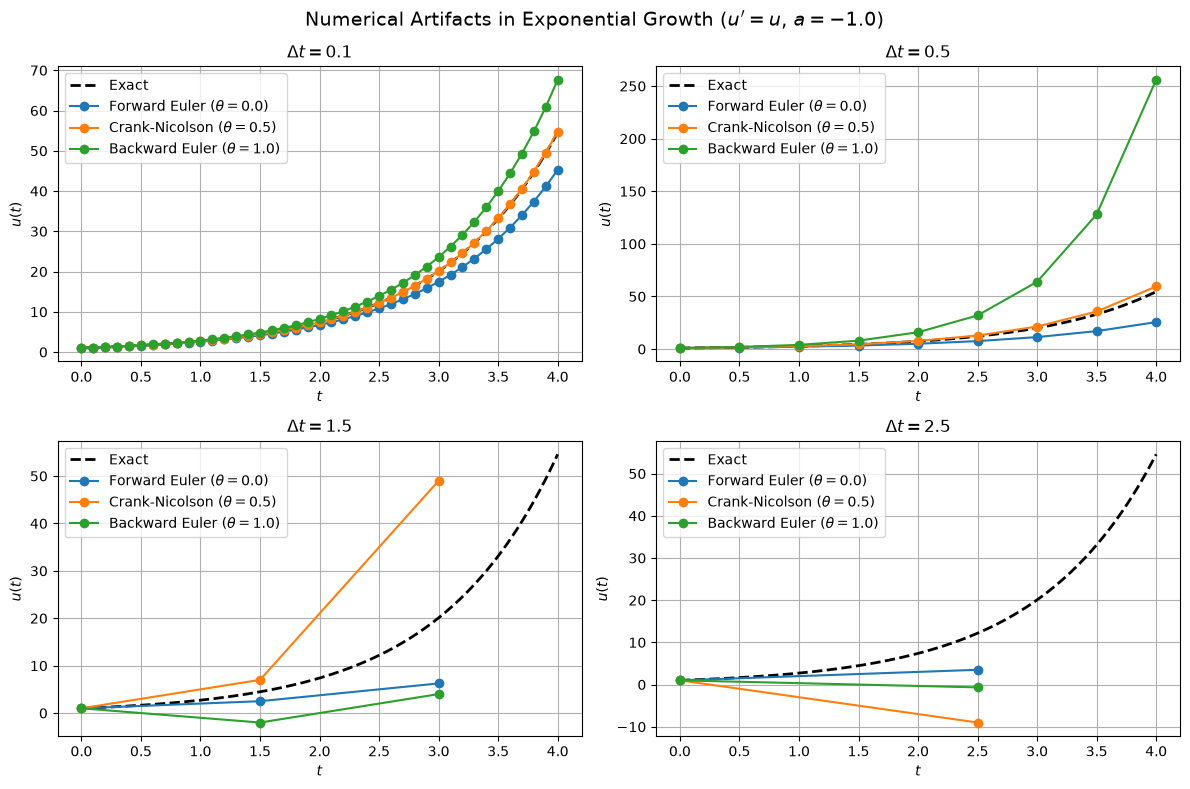

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)
axes = axes.flatten()

for i, dt in enumerate(dt_values):
    ax = axes[i]
    
    # plot exact solution
    t_exact = np.linspace(0, T, 200)
    ax.plot(t_exact, exact_solution(t_exact, I, a), 'k--', label='Exact', linewidth=2)
    
    # numerical solutions for the three theta values
    for theta, label in thetas.items():
        u, t = solver(I, a, T, dt, theta)
        ax.plot(t, u, 'o-', label=f'{label} ($\\theta={theta}$)')
        
    ax.set_title(f'$\\Delta t = {dt}$')
    ax.set_xlabel('$t$')
    ax.set_ylabel('$u(t)$')
    ax.grid(True)
    ax.legend(loc='upper left')

plt.suptitle(f'Numerical Artifacts in Exponential Growth ($u\' = u$, $a={a}$)', fontsize=14)
plt.tight_layout()
plt.savefig('exponential_growth_artifacts.png')
plt.show()

## Part b)

Write up the amplification factor and plot it for $\theta=0, 0.5, 1$ together with the exact one for $a\Delta t < 0$. Use the plot to explain the observations made in the experiments.

**Hint.** Modify the `decay_ampf_plot.py` code (in the src/analysis directory).

### Parameters

In [22]:
I = 1.0     # initial value u(0)
a = -1.0    # a < 0 gives exponential growth u' = u
T = 4.0     # end point

# domain for the amplification factor plot: p = a * dt < 0
# we test values of (a * dt) from -3.0 to 0
p = np.linspace(-3.0, 0.0, 100)

thetas = {0.0: 'Forward Euler', 0.5: 'Crank-Nicolson', 1.0: 'Backward Euler'}

### Visualization

/var/folders/10/5n_tqm9j1nvc58q0wvcg2zt40000gn/T/ipykernel_45110/1291327855.py:8: RuntimeWarning: divide by zero encountered in divide
  plt.plot(p, (1 - 0.5 * p) / (1 + 0.5 * p), 'r-^', label='CN', markevery=10)
/var/folders/10/5n_tqm9j1nvc58q0wvcg2zt40000gn/T/ipykernel_45110/1291327855.py:9: RuntimeWarning: divide by zero encountered in divide
  plt.plot(p, 1 / (1 + p), 'b-s', label='BE', markevery=10)


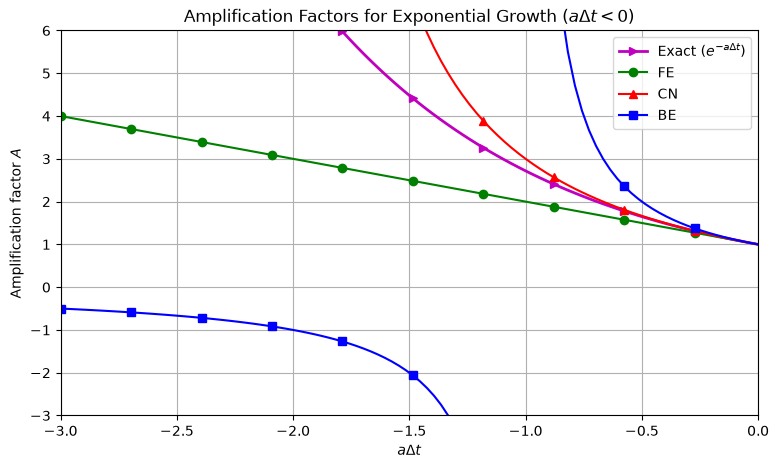

In [28]:
# exact amplification factor A_e = exp(-a * dt)
A_e = np.exp(-p)

plt.figure(figsize=(9, 5))
plt.plot(p, A_e, 'm->', label='Exact ($e^{-a\\Delta t}$)', linewidth=2, markevery=10)

plt.plot(p, 1 - p, 'g-o', label='FE', markevery=10)
plt.plot(p, (1 - 0.5 * p) / (1 + 0.5 * p), 'r-^', label='CN', markevery=10)
plt.plot(p, 1 / (1 + p), 'b-s', label='BE', markevery=10)

plt.xlabel('$a \\Delta t$')
plt.ylabel('Amplification factor $A$')
plt.title('Amplification Factors for Exponential Growth ($a \\Delta t < 0$)')

plt.ylim(-3, 6)
plt.xlim(-3, 0)

plt.grid(True)
plt.legend()
plt.show()